In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline


In [2]:
## lets import the cleaned dataset
df=pd.read_csv('3.algerian_forest_fires_cleaned_dataset.csv')

In [3]:
df.head()
## here WFI is the target variable and rest are the features


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
## lets drop unnecessary columns
df.drop(['day','month','year'],axis=1,inplace=True)

In [5]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [6]:
## we have classes as a column which is a categorical variable we need to convert it into numerical variable using encoding
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [7]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)

In [8]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [9]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [10]:
## lets divide the features into independent and dependent features
X=df.drop('FWI',axis=1)## because ever feature except FWI is independent feature
y=df['FWI']## because FWI is the target variable

In [11]:
print(X)
print(y)

     Temperature  RH  Ws  Rain  FFMC   DMC    DC  ISI   BUI  Classes  region
0             29  57  18   0.0  65.7   3.4   7.6  1.3   3.4        0       0
1             29  61  13   1.3  64.4   4.1   7.6  1.0   3.9        0       0
2             26  82  22  13.1  47.1   2.5   7.1  0.3   2.7        0       0
3             25  89  13   2.5  28.6   1.3   6.9  0.0   1.7        0       0
4             27  77  16   0.0  64.8   3.0  14.2  1.2   3.9        0       0
..           ...  ..  ..   ...   ...   ...   ...  ...   ...      ...     ...
238           30  65  14   0.0  85.4  16.0  44.5  4.5  16.9        1       1
239           28  87  15   4.4  41.1   6.5   8.0  0.1   6.2        0       1
240           27  87  29   0.5  45.9   3.5   7.9  0.4   3.4        0       1
241           24  54  18   0.1  79.7   4.3  15.2  1.7   5.1        0       1
242           24  64  15   0.2  67.3   3.8  16.5  1.2   4.8        0       1

[243 rows x 11 columns]
0      0.5
1      0.4
2      0.1
3      0.0
4      

In [12]:
## now we have to do a train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [13]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((182, 11), (61, 11), (182,), (61,))

In [14]:
## now lets do a feature selection based on correlation
## now lets check the correlation between the features
X_train.corr()## this will give us the correlation between the independent features


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

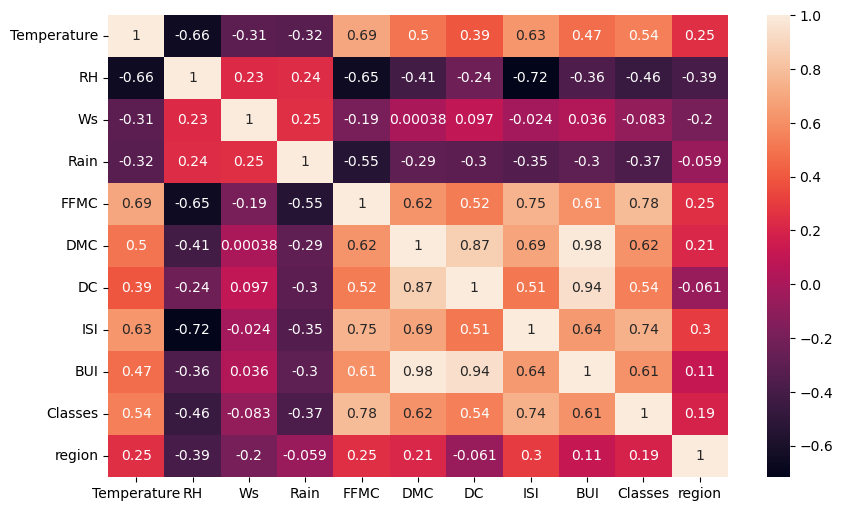

In [15]:
## now lets see this is a heat map of the correlation between the features
plt.figure(figsize=(10,6))
sns.heatmap(X_train.corr(),annot=True)

## Now with correlation we can make thease assumptions that 

1. Correlation between independent variables (multicollinearity removal)

Here, you calculate the correlation among the input features themselves.

Suppose:

Feature	  Age	   Experience	Salary

Age	       1.00	        0.92	  0.70

Experience	0.92	    1.00	  0.75

Salary	    0.70	    0.75	   1.00

Notice:

Age and Experience have correlation = 0.92
They contain almost the same information.
Keeping both may introduce multicollinearity.
so we remove one of them

A common rule:

If ∣r∣>0.8 or ∣r∣>0.9, remove one of the two features.

You can keep:

Age and Salary

or

Experience and Salary

but not both Age and Experience.

In [16]:
## so using assumption 1
## lets check the multicollinearity between the features 

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of columns that are correlated with other above the threshold basically a set
    corr_matrix = dataset.corr() ## this give above correlation matrix
    for i in range(len(corr_matrix.columns)): ## number object of columns in the dataset/correlation matrix
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]  # getting the name of column that are greater than the threshold
                col_corr.add(colname) ## adding the name of the column to the set
                
    return col_corr

In [17]:
## threshold can be set with the help of domain expert
corr_features=correlation(X_train,0.85)## this will give us the name of the columns that are correlated with other above the threshold of 0.85

In [18]:
## lets drop the correlated features from the dataset
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)## also drop from the test data also

In [19]:
X_train.shape,X_test.shape,

((182, 9), (61, 9))

## there is also another assumption
2. Correlation between features and the target (most common)

You calculate the correlation between each input feature X and the target variable y.

Keep features with high correlation to the target.
Remove features with very low correlation to the target.

Example:

Feature	          Correlation with Target

Age	                        0.72

Salary	                    0.68

Height	                    0.05

You would likely keep Age and Salary, and remove Height.


## Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [21]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]])

## box plot to understand the effect of stamdard scalar

Text(0.5, 1.0, 'X_train after scaling')

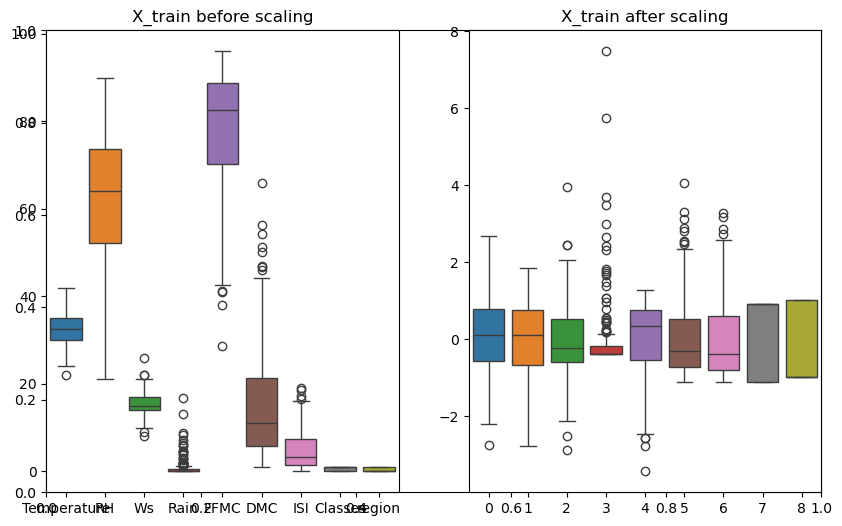

In [22]:
plt.subplots(figsize=(10,6))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train before scaling')

plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train after scaling')

In [23]:
## here we can see that after scaling the data is in the same range and mean is also 0 and standard deviation is 1

## Linear Regression Model

In [24]:
from sklearn.linear_model import LinearRegression
linear_model=LinearRegression()


In [25]:
linear_model.fit(X_train_scaled,y_train)


LinearRegression()

In [26]:
## lets compute mean absolute error and mean squared error
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
y_pred=linear_model.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2_score=r2_score(y_test,y_pred)
print('Mean Absolute Error:',mae)
print('Mean Squared Error:',mse)
print('R2 Score:',r2_score)

Mean Absolute Error: 0.5468236465249976
Mean Squared Error: 0.6742766873791581
R2 Score: 0.9847657384266951


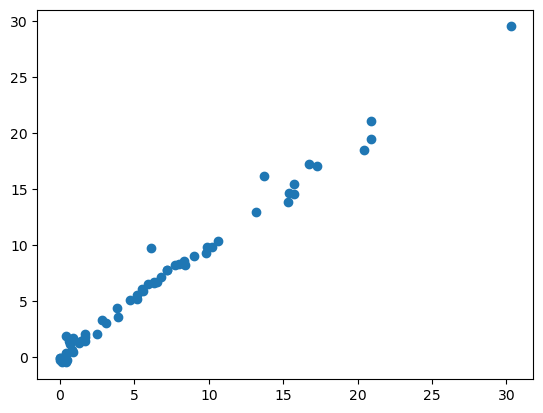

In [27]:
## lets visualize the predicted vs actual values
plt.scatter(y_test,y_pred)

## if it is following a linear pattern then our model is good otherwise we need to do some feature engineering or try some other model

In [28]:
## now lets apply lasso regression
from sklearn.linear_model import Lasso
lasso_model=Lasso(alpha=0.1)## alpha is the regularization parameter
lasso_model.fit(X_train_scaled,y_train)

Lasso(alpha=0.1)

In [29]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
y_pred_lasso=lasso_model.predict(X_test_scaled)
mae_lasso=mean_absolute_error(y_test,y_pred_lasso)
mse_lasso=mean_squared_error(y_test,y_pred_lasso)
r2_lasso=r2_score(y_test,y_pred_lasso)
print('Mean Absolute Error:',mae_lasso)
print('Mean Squared Error:',mse_lasso)
print('R2 Score:',r2_lasso)


Mean Absolute Error: 0.7084773819658261
Mean Squared Error: 0.9593621779333094
R2 Score: 0.9783246631008717


## Here we have taken some random values of alpha and l1_ratio we can do hyperparameter tuning to find the best values of alpha and l1_ratio for our model
 for that we will do cross validation
 
 cross validation is a technique to evaluate the performance of the model on unseen data by splitting the data into k folds and then training the model on k-1 folds and testing on the remaining fold and then repeating this process k times and then taking the average of the performance metrics

## cross validation lasso

In [30]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)## cv is the number of folds for cross validation
lassocv.fit(X_train_scaled,y_train)## we will do validation on ttaining data and then we will get the best alpha value for lasso regression

LassoCV(cv=5)

In [31]:
lassocv.alpha_## this will give us the best alpha value for lasso regression

0.05725391318234408

In [32]:
lassocv.alphas_## this will give us the list of alpha values that were tested during cross-validation basically the range of alpha values that were tested during cross-validation to select the best one among them

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

In [33]:


y_pred_lassocv=lassocv.predict(X_test_scaled)
## here we are predicting the values for the test set using the best alpha value found through cross-validation

In [34]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
mae_lassocv=mean_absolute_error(y_test,y_pred_lassocv)
mse_lassocv=mean_squared_error(y_test,y_pred_lassocv)
r2_lassocv=r2_score(y_test,y_pred_lassocv)
print('Mean Absolute Error:',mae_lassocv)
print('Mean Squared Error:',mse_lassocv)

Mean Absolute Error: 0.6199701158263431
Mean Squared Error: 0.7924995554743622


## ridge regression


In [35]:
## for ridge regression we can do the same thing we just need to import Ridge from sklearn.linear_model and then fit the model and then compute the metrics
from sklearn.linear_model import Ridge
ridge_model=Ridge(alpha=0.1)
ridge_model.fit(X_train_scaled,y_train)

Ridge(alpha=0.1)

In [36]:
ridge_model.fit(X_train_scaled,y_train)
y_pred_ridge=ridge_model.predict(X_test_scaled)
mae_ridge=mean_absolute_error(y_test,y_pred_ridge)
mse_ridge=mean_squared_error(y_test,y_pred_ridge)
r2_ridge=r2_score(y_test,y_pred_ridge)
print('Mean Absolute Error:',mae_ridge)
print('Mean Squared Error:',mse_ridge)
print('R2 Score:',r2_ridge)


Mean Absolute Error: 0.5481365412366674
Mean Squared Error: 0.6761290141895067
R2 Score: 0.9847238879049787


In [37]:
## similarly we could do the same thing for ridge regression with cross-validation using RidgeCV from sklearn.linear_model
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)## this will give us the best alpha value for ridge regression

RidgeCV(cv=5)

In [38]:
ridgecv.alpha_ ## this will give us the best alpha value for ridge regression

1.0

In [39]:
y_pred_ridgecv=ridgecv.predict(X_test_scaled)
mae_ridgecv=mean_absolute_error(y_test,y_pred_ridgecv)
mse_ridgecv=mean_squared_error(y_test,y_pred_ridgecv)
r2_ridgecv=r2_score(y_test,y_pred_ridgecv)
print('Mean Absolute Error:',mae_ridgecv)
print('Mean Squared Error:',mse_ridgecv)
print('R2 Score:',r2_ridgecv)


Mean Absolute Error: 0.5642305340105693
Mean Squared Error: 0.6949198918152067
R2 Score: 0.9842993364555513


## Elastic Net Regression
Elastic Net is a linear regression model that combines the penalties of Lasso and Ridge regression. It is useful when there are multiple features that are correlated with each other. The Elastic Net penalty is a combination of the L1 and L2 penalties, which can help to reduce the bias of the model while also reducing the variance.

In [40]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.linear_model import ElasticNet
elastic_model=ElasticNet(alpha=0.1,l1_ratio=0.5)## l1_ratio is the ratio of lasso and ridge regression
elastic_model.fit(X_train_scaled,y_train)
y_pred_elastic=elastic_model.predict(X_test_scaled)
mae_elastic=mean_absolute_error(y_test,y_pred_elastic)
mse_elastic=mean_squared_error(y_test,y_pred_elastic)
r2_elastic=r2_score(y_test,y_pred_elastic)
print('Mean Absolute Error:',mae_elastic)
print('Mean Squared Error:',mse_elastic)
print('R2 Score:',r2_elastic)


Mean Absolute Error: 0.8291276215817327
Mean Squared Error: 1.1245702037934004
R2 Score: 0.9745920377156688


In [41]:
## for elasticnet regression with cross-validation we can use ElasticNetCV from sklearn.linear_model
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)## this will give us the best alpha value for elasticnet regression    


ElasticNetCV(cv=5)

In [42]:
print('Best alpha value for elasticnet regression:',elasticcv.alpha_ )
print('Best l1_ratio value for elasticnet regression:',elasticcv.l1_ratio_)

## by default l1 is 0.5 which means equal contribution of lasso and ridge regression but we can change it according to our needs and then we can get the best alpha value for elasticnet regression using cross-validation

Best alpha value for elasticnet regression: 0.04311146156383891
Best l1_ratio value for elasticnet regression: 0.5


In [43]:
y_pred_elasticcv=elasticcv.predict(X_test_scaled)
mae_elasticcv=mean_absolute_error(y_test,y_pred_elasticcv)
mse_elasticcv=mean_squared_error(y_test,y_pred_elasticcv)
r2_elasticcv=r2_score(y_test,y_pred_elasticcv)
print('Mean Absolute Error:',mae_elasticcv)
print('Mean Squared Error:',mse_elasticcv)
print('R2 Score:',r2_elasticcv)


Mean Absolute Error: 0.6575946731430904
Mean Squared Error: 0.8222830416276272
R2 Score: 0.9814217587854941


In [44]:
## now lets pickle the best model that is right now ridge regression 
## we also pickle the scaler object because we need to scale the new data before making predictions with the model
scaler

StandardScaler()

In [45]:
ridge_model

Ridge(alpha=0.1)

In [46]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))## this will save the scaler object in a file named scaler.pkl in write binary mode
pickle.dump(ridge_model,open('ridge_model.pkl','wb'))## this will save the model in a file named ridge_model.pkl in write binary mode


## now we will convert it into an end to end project where we will create a web application using flask and then we will deploy it on AWS so that anyone can use it to make predictions on new data 